### **[Turning Customer Behavior into Purchase Predictions](https://medium.com/@nomannayeem/c34a0c6302c7)**

> *How Businesses Can Leverage Logistic Regression and FastAPI to Anticipate Customer Actions*

In [1]:
import sys

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 1200)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.precision', 4)
pd.set_option('display.max_rows', None)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 8

sns.set_style('whitegrid')

%autosave 15

Autosaving every 15 seconds


#### **Building the Complete Prediction Model**

In [2]:
# Sample code to generate synthetic data for demonstration
# In a real project, you would load your actual customer data

# Create synthetic customer data
n_samples = 3000
age = np.random.normal(40, 15, n_samples)
time_spent_on_site = np.random.exponential(5, n_samples)
pages_visited = np.random.poisson(5, n_samples)
previous_purchases = np.random.poisson(2, n_samples)
cart_value = np.random.exponential(50, n_samples)
is_returning_customer = np.random.binomial(1, 0.3, n_samples)
days_since_last_visit = np.random.exponential(30, n_samples)

# Create purchase probability based on features
purchase_prob = (0.02
                 + 0.001 * (age - 40)
                 + 0.05 * time_spent_on_site
                 + 0.03 * pages_visited
                 + 0.1 * previous_purchases
                 + 0.001 * cart_value
                 + 0.2 * is_returning_customer
                 - 0.003 * days_since_last_visit)

# Ensure probabilities are between 0 and 1
purchase_prob = np.clip(purchase_prob, 0, 0.9)

# Generate target variable: purchased (1) or not (0)
purchased = np.random.binomial(1, purchase_prob)

# Create dataframe
customer_data = pd.DataFrame({
  'age': age,
  'time_spent_on_site': time_spent_on_site,
  'pages_visited': pages_visited,
  'previous_purchases': previous_purchases,
  'cart_value': cart_value,
  'is_returning_customer': is_returning_customer,
  'days_since_last_visit': days_since_last_visit,
  'purchased': purchased
})

# Display the first few rows
display(customer_data.head(10))

,age,time_spent_on_site,pages_visited,previous_purchases,cart_value,is_returning_customer,days_since_last_visit,purchased
0,47.45,8.54,6,2,38.29,0,4.89,1
1,37.93,20.54,3,2,1.17,1,49.03,1
2,49.72,1.50,6,4,78.45,0,16.56,1
3,62.85,17.49,7,0,48.42,0,6.17,0
4,36.49,2.82,7,0,10.67,0,15.44,0
5,36.49,2.13,5,3,12.13,1,7.51,1
6,63.69,0.26,3,1,15.22,1,4.39,1
7,51.51,0.27,4,1,42.96,0,8.20,0
8,32.96,5.89,4,3,39.74,1,60.61,0
9,48.14,3.06,5,0,16.00,0,3.36,0


In [3]:
# Basic information
display(customer_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    3000 non-null   float64
 1   time_spent_on_site     3000 non-null   float64
 2   pages_visited          3000 non-null   int64  
 3   previous_purchases     3000 non-null   int64  
 4   cart_value             3000 non-null   float64
 5   is_returning_customer  3000 non-null   int64  
 6   days_since_last_visit  3000 non-null   float64
 7   purchased              3000 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 187.6 KB


None

In [4]:
# Basic statistics
display(customer_data.describe())

,age,time_spent_on_site,pages_visited,previous_purchases,cart_value,is_returning_customer,days_since_last_visit,purchased
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,40.48,4.93,5.06,1.96,48.99,0.30,30.70,0.58
std,14.80,4.96,2.26,1.37,48.97,0.46,31.30,0.49
min,-8.62,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.59,1.42,3.00,1.00,13.95,0.00,8.72,0.00
50%,40.37,3.35,5.00,2.00,33.79,0.00,20.82,1.00
75%,50.10,6.78,6.25,3.00,67.80,1.00,42.93,1.00
max,98.89,37.63,15.00,9.00,359.15,1.00,273.61,1.00


In [5]:
# Check for missing values
print("Missing values:")
display(customer_data.isnull().sum())

# Distribution of target variable
print("Purchase distribution:")
display(customer_data['purchased'].value_counts(normalize=True))

Missing values:


,0
age,0
time_spent_on_site,0
pages_visited,0
previous_purchases,0
cart_value,0
is_returning_customer,0
days_since_last_visit,0
purchased,0


Purchase distribution:


,proportion
purchased,
1,0.58
0,0.42


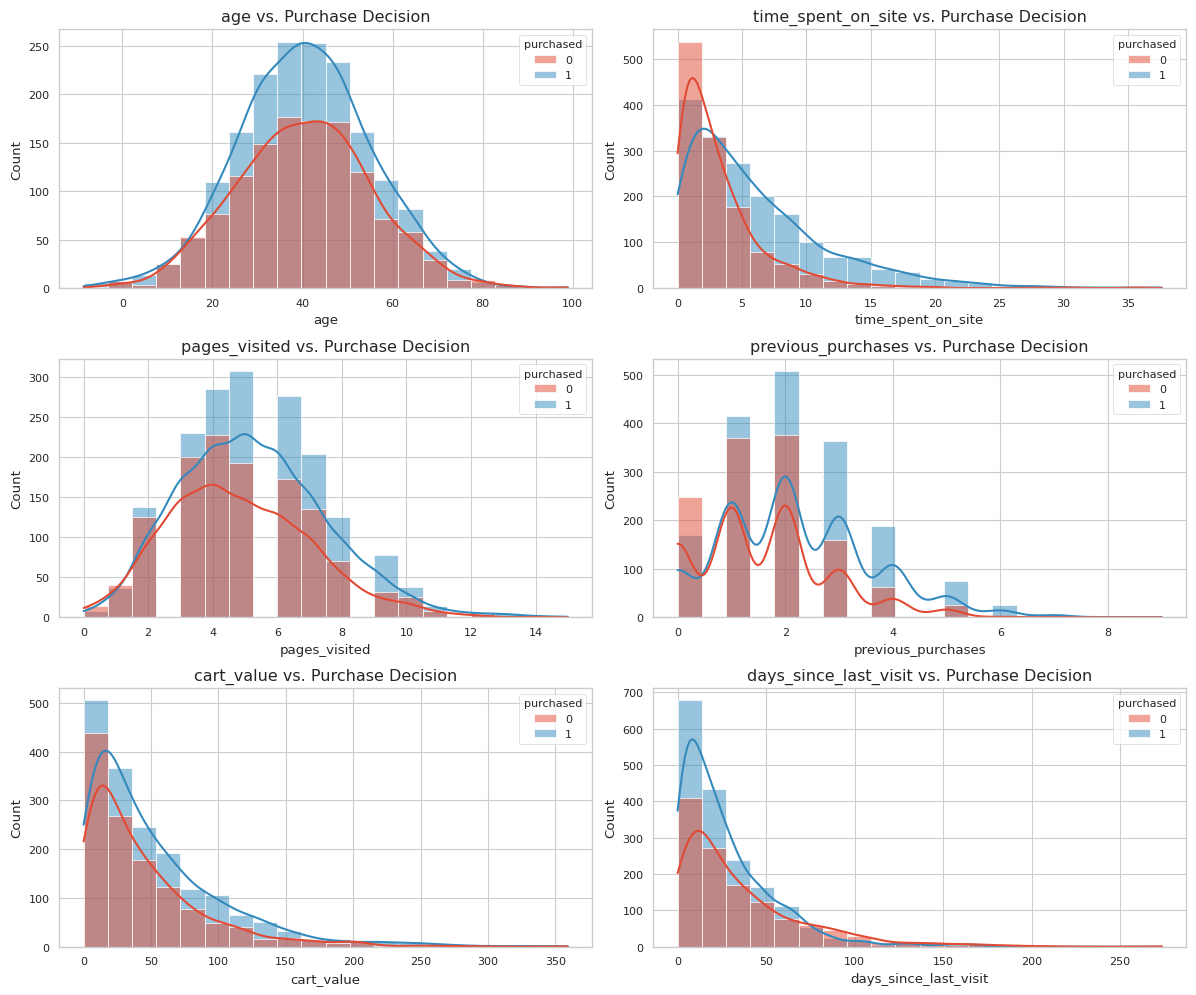

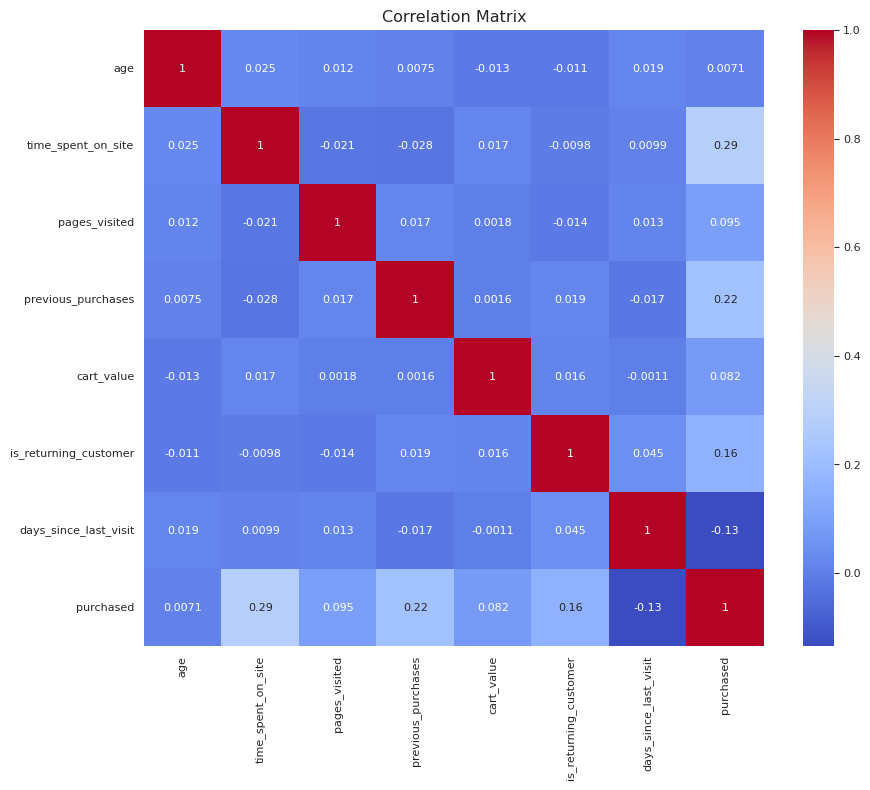

In [6]:
# Visualize relationships
plt.figure(figsize=(12, 10))

# Distribution of numerical features by purchase decision
features = ['age', 'time_spent_on_site', 'pages_visited', 'previous_purchases',
          'cart_value', 'days_since_last_visit']

for i, feature in enumerate(features):
  plt.subplot(3, 2, i+1)
  sns.histplot(data=customer_data, x=feature, hue='purchased', bins=20, kde=True)
  plt.title(f'{feature} vs. Purchase Decision')
  plt.tight_layout()

plt.figure(figsize=(10, 8))
correlation = customer_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### **Feature Engineering: Transforming Raw Data into Predictive Signals**

In [7]:
from sklearn.model_selection import train_test_split

# Feature engineering
customer_data['recency_score'] = 1 / (1 + customer_data['days_since_last_visit'])
customer_data['engagement_score'] = (customer_data['time_spent_on_site'] * customer_data['pages_visited']) / 10

# Create feature matrix X and target variable y
X = customer_data.drop('purchased', axis=1)
y = customer_data['purchased']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 2400 samples
Test set: 600 samples


#### **Building the Model Pipeline**

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create a pipeline with preprocessing and model
pipeline = Pipeline([
  ('scaler', StandardScaler()),  # Standardize features
  ('classifier', LogisticRegression(random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Extract the logistic regression model
model = pipeline.named_steps['classifier']

# Get feature coefficients
coefficients = pd.DataFrame({
  'Feature': X_train.columns,
  'Coefficient': model.coef_[0]
})

# Sort by absolute coefficient value
coefficients = coefficients.reindex(
  coefficients['Coefficient'].abs().sort_values(ascending=False).index
)

print("Feature Importance:")
display(coefficients)

Feature Importance:


,Feature,Coefficient
1,time_spent_on_site,0.86
3,previous_purchases,0.58
5,is_returning_customer,0.40
6,days_since_last_visit,-0.34
2,pages_visited,0.21
4,cart_value,0.17
7,recency_score,0.05
8,engagement_score,0.04
0,age,-0.00


#### **Model Evaluation: Measuring Prediction Performance**

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.65      0.65       249
           1       0.75      0.77      0.76       351

    accuracy                           0.72       600
   macro avg       0.71      0.71      0.71       600
weighted avg       0.72      0.72      0.72       600



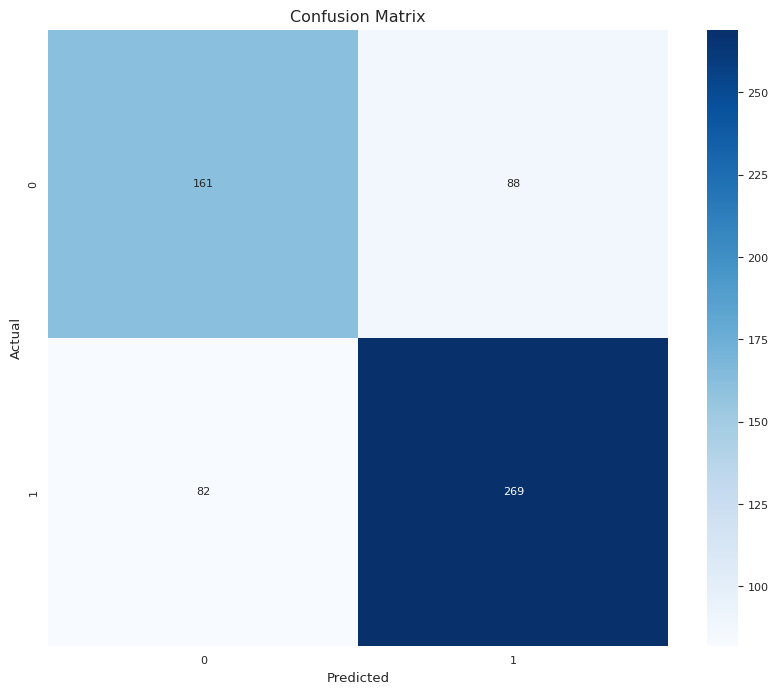

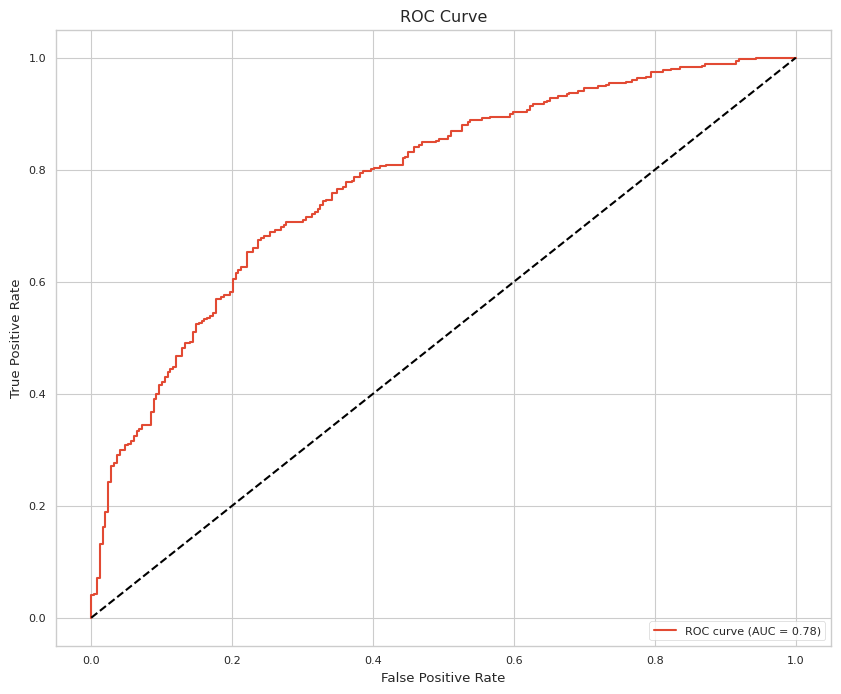

Cross-validation accuracy: 0.71 (+/- 0.02)


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score

# Predictions
y_pred = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Cross-validation
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

#### **Interpreting the Model: From Coefficients to Business Insights**

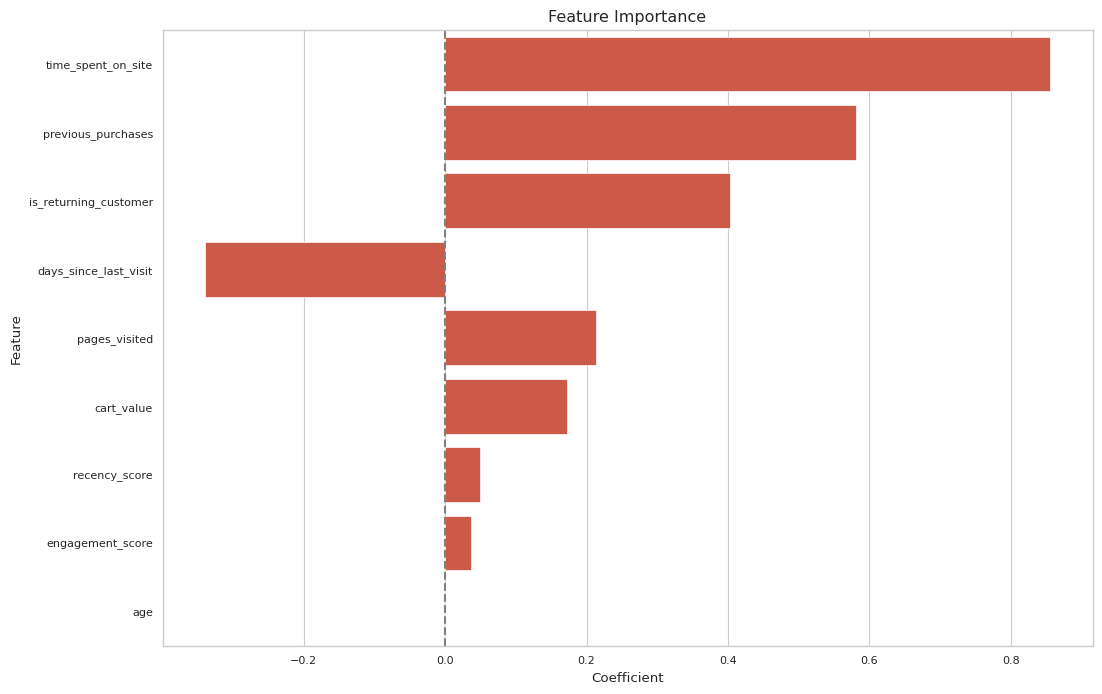

Odds Ratios (impact on purchase probability):


,Feature,Odds Ratio,Coefficient
1,time_spent_on_site,2.35,0.86
3,previous_purchases,1.79,0.58
5,is_returning_customer,1.50,0.40
2,pages_visited,1.24,0.21
4,cart_value,1.19,0.17
7,recency_score,1.05,0.05
8,engagement_score,1.04,0.04
0,age,1.00,-0.00
6,days_since_last_visit,0.71,-0.34


In [10]:
# Feature importance visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance')
plt.axvline(x=0, color='gray', linestyle='--')
plt.show()

# Calculate odds ratios for better interpretation
odds_ratios = pd.DataFrame({
  'Feature': X_train.columns,
  'Odds Ratio': np.exp(model.coef_[0]),
  'Coefficient': model.coef_[0]
})

print("Odds Ratios (impact on purchase probability):")
display(odds_ratios.sort_values('Odds Ratio', ascending=False))

#### **Making Predictions on New Customers**

In [11]:
# Function to predict purchase probability for new customers
def predict_purchase_probability(new_customer_data, pipeline):
  """
  Predict the probability of purchase for new customers.

  Parameters:
  new_customer_data (DataFrame): Customer features
  pipeline: Trained model pipeline

  Returns:
  DataFrame: Original data with purchase probabilities
  """
  # Make a copy to avoid modifying the original
  df = new_customer_data.copy()

  # Add engineered features if they're not already present
  if 'recency_score' not in df.columns:
    df['recency_score'] = 1 / (1 + df['days_since_last_visit'])
  if 'engagement_score' not in df.columns:
    df['engagement_score'] = (df['time_spent_on_site'] * df['pages_visited']) / 10

  # Get predictions
  purchase_prob = pipeline.predict_proba(df)[:, 1]

  # Add predictions to the dataframe
  df['purchase_probability'] = purchase_prob
  df['likely_to_purchase'] = purchase_prob >= 0.5

  return df

# Example of using the function with new customer data
new_customers = pd.DataFrame({
  'age': [25, 45, 65],
  'time_spent_on_site': [2, 8, 1],
  'pages_visited': [3, 12, 2],
  'previous_purchases': [0, 5, 1],
  'cart_value': [20, 150, 30],
  'is_returning_customer': [0, 1, 1],
  'days_since_last_visit': [0, 5, 60]
})

# Generate predictions
predictions = predict_purchase_probability(new_customers, pipeline)
print("Purchase Predictions:")
display(predictions[['age', 'previous_purchases', 'purchase_probability', 'likely_to_purchase']])

Purchase Predictions:


,age,previous_purchases,purchase_probability,likely_to_purchase
0,25,0,0.31,False
1,45,5,0.99,True
2,65,1,0.33,False


#### **Saving the Model for Deployment**

In [12]:
import joblib
if not IN_COLAB:
  joblib.dump(pipeline, 'purchase_prediction_model.pkl')